In [14]:
import os
from dotenv import load_dotenv
load_dotenv()
from langgraph.graph import StateGraph,START,END
from langgraph.checkpoint.memory import MemorySaver
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages
from langchain_core.tools import tool
from langchain_core.messages import BaseMessage
from langgraph.prebuilt import ToolNode,tools_condition

In [7]:
os.environ["LANGSMITH_PROJECT"] = "Test project"


In [19]:
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["LANGSMITH_API_KEY"] = os.getenv("LANGSMITH_API_KEY")
os.environ["LANGSMITH_TRACING"]="true"

In [20]:
from langchain.chat_models import init_chat_model

llm = init_chat_model("groq:llama-3.3-70b-versatile")
llm

ChatGroq(output_version=None, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001A6B090A990>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001A6B090B390>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [21]:
class state(TypedDict):
    messages:Annotated[list[BaseMessage],add_messages]

In [12]:
@tool
def add(a:float,b:float):
    """Add two number"""
    
    return a+b

tools=[add]
tool_node = ToolNode(tools)

llm_with_tools = llm.bind_tools(tools)


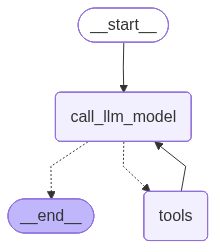

In [16]:
def call_llm_model(state:state):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

builder = StateGraph(state)
builder.add_node("call_llm_model",call_llm_model)
builder.add_node("tools",tool_node)
builder.add_edge(START,"call_llm_model")
builder.add_conditional_edges("call_llm_model",tools_condition)
builder.add_edge("tools","call_llm_model")

graph = builder.compile()

from IPython.display import Image,display
display(Image(graph.get_graph().draw_mermaid_png()))


In [22]:
response = graph.invoke({"messages":"what is machine learning"})

In [23]:
response


{'messages': [HumanMessage(content='what is machine learning', additional_kwargs={}, response_metadata={}, id='dbe818db-856e-4f04-9116-ef53dfa4fab5'),
  AIMessage(content="Machine learning is a subset of artificial intelligence (AI) that involves the use of algorithms and statistical models to enable machines to perform a specific task without using explicit instructions. Instead, the machine learns from data, making predictions or decisions based on that data.\n\nThere are several key aspects of machine learning:\n\n1. **Data**: Machine learning relies on large amounts of data to learn from. This data can come in many forms, such as images, text, audio, or sensor readings.\n2. **Algorithms**: Machine learning algorithms are used to analyze the data and make predictions or decisions. These algorithms can be categorized into different types, such as supervised, unsupervised, and reinforcement learning.\n3. **Training**: The machine learning model is trained on the data, which involves a